[{'pais': 'Spain', 'indicador': 'GDP (current US$)', 'ano': '2024', 'valor': 1725671652742.19}, {'pais': 'Spain', 'indicador': 'GDP (current US$)', 'ano': '2023', 'valor': 1619481980719.64}, {'pais': 'Spain', 'indicador': 'GDP (current US$)', 'ano': '2022', 'valor': 1448850658406.62}, {'pais': 'Spain', 'indicador': 'GDP (current US$)', 'ano': '2021', 'valor': 1461244901852.69}, {'pais': 'Spain', 'indicador': 'GDP (current US$)', 'ano': '2020', 'valor': 1289783836971.21}]
Total registros:  60
  country  year         value
0   Spain  2024  1.725672e+12
1   Spain  2023  1.619482e+12
2   Spain  2022  1.448851e+12
3   Spain  2021  1.461245e+12
4   Spain  2020  1.289784e+12


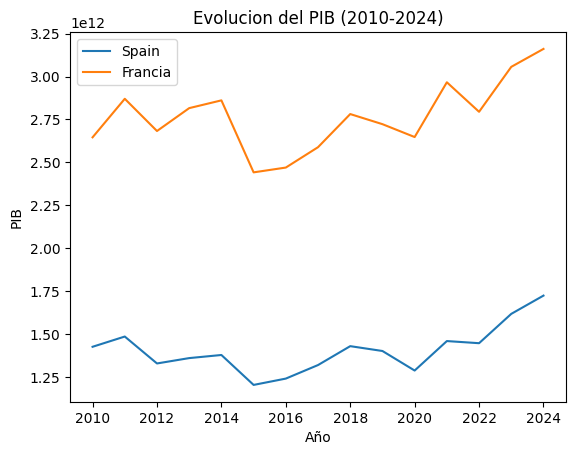

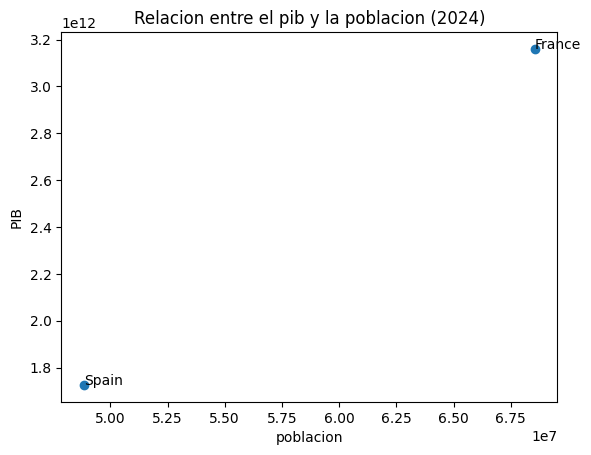

   country  year         value
0    Spain  2024  1.725672e+12
1    Spain  2023  1.619482e+12
2    Spain  2022  1.448851e+12
3    Spain  2021  1.461245e+12
4    Spain  2020  1.289784e+12
5    Spain  2019  1.403496e+12
6    Spain  2018  1.431643e+12
7    Spain  2017  1.321754e+12
8    Spain  2016  1.243016e+12
9    Spain  2015  1.206165e+12
10   Spain  2014  1.380245e+12
11   Spain  2013  1.362187e+12
12   Spain  2012  1.330995e+12
13   Spain  2011  1.487569e+12
14   Spain  2010  1.427989e+12
15  France  2024  3.160443e+12
16  France  2023  3.056251e+12
17  France  2022  2.794788e+12
18  France  2021  2.966434e+12
19  France  2020  2.647926e+12
20  France  2019  2.722794e+12
21  France  2018  2.781576e+12
22  France  2017  2.588868e+12
23  France  2016  2.470408e+12
24  France  2015  2.442483e+12
25  France  2014  2.861236e+12
26  France  2013  2.816078e+12
27  France  2012  2.683007e+12
28  France  2011  2.870409e+12
29  France  2010  2.646230e+12


In [15]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

#PASO3

#paises e indicadores que voy a utilizar 
paises = ["ES","FR"]
indicadores = ["NY.GDP.MKTP.CD","SP.POP.TOTL"]

#lista dodne vamos a guardar los datos
data_list = []

#bucle por cada pais y por cada indicador
for pais in paises:
    for indicador in indicadores:
        
        page = 1
        
        while True:
        #url con su pais y su indicador
            url = f"https://api.worldbank.org/v2/country/{pais}/indicator/{indicador}"

        #parametros de la peticion
            params = {
                "format": "json",
                "per_page": 50,
                "page": page,
                "date" : "2010:2024"
            }
        #hacemos la peticion a la api
            response = requests.get(url, params=params, timeout=30)
        #lanza error sui la peticion falla
            response.raise_for_status()
        #convertimos la respuesta a json
            payload = response.json()

        #datos reales,porque la api devuyelve metadatos
            results = payload[1]

#recorremos cada registro
            for item in results:
            #creamos el diccionario con los datos importantes que queremos traer de la api
                datos = {
                "pais":item["country"]["value"],
                "indicador":item["indicator"]["value"],
                "ano":item["date"],
                "valor":item["value"]
                }
            #añadimos el registro a la lista
                data_list.append(datos)

        #obtenemso el numero total de paginas
            total_paginas = payload[0]["pages"]
        #si ya estamo sn el ultima pagina salimos 
            if page >= total_paginas:
                break
        #si no,pasamos a la siguiente pagina
            page += 1

#primeros 5 registros
print (data_list[:5])
#mostramos la cantidad de registros que hemos traido a la lista
print ("Total registros: ",len(data_list))


#PASO 4
#convertimos la lista en dataframe
df = pd.DataFrame(data_list) 

#renombramos las columnas 
df = df.rename(columns={
    "pais": "country",
    "ano": "year",
    "valor": "value"
})

#lsita de indicadores unicos
indicadores = df["indicador"].unique()

#diccionario para guardar los dataframes
diccionario_indicadores = {}

#recorremos cada indicador
for indi in indicadores:

    #filtramos solo ese indicador
    df_indicadores_filtros = df[df["indicador"] == indi].copy()

    #convertimso lso tipos de datos
    df_indicadores_filtros["year"] = df_indicadores_filtros["year"].astype(int)
    df_indicadores_filtros["value"] = pd.to_numeric(df_indicadores_filtros["value"])

    #eliminar valore snulos
    df_indicadores_filtros = df_indicadores_filtros.dropna(subset=["value"])

    #nos quedamos solo con las columnas necesarias
    df_indicadores_filtros = df_indicadores_filtros[["country","year","value"]]

    #guardamos los datos en el diccionario
    diccionario_indicadores[indi] = df_indicadores_filtros


#mostramos un indicador
primer_indicador = list(diccionario_indicadores.keys())[0]
print (diccionario_indicadores[primer_indicador].head())





#PASO 5
#primer grafico
#seleccionamos el dataframe del pib
df_pib = diccionario_indicadores["GDP (current US$)"]

#filtramos los paises
esp = df_pib[df_pib["country"] == "Spain"]
fra = df_pib[df_pib["country"] == "France"]

#creamos elñ grafico
plt.figure()

plt.plot(esp["year"],esp["value"], label = "Spain")
plt.plot(fra["year"],fra["value"], label = "Francia")

plt.xlabel ("Año")
plt.ylabel ("PIB")
plt.title ("Evolucion del PIB (2010-2024)")
plt.legend()

plt.show()

#segundo grafico
#dataframes que cogemos
df_pib = diccionario_indicadores["GDP (current US$)"]
df_pob = diccionario_indicadores["Population, total"]

#filtramos por año 2024
pib_2024 = df_pib[df_pib["year"] == 2024]
pop_2024 = df_pob[df_pob["year"] == 2024]

#unimos por pais
df_merge = pib_2024.merge(pop_2024,on="country",suffixes=("_pib","_pop"))

#pintamos el scatter plot
plt.figure()

plt.scatter(df_merge["value_pop"],df_merge["value_pib"])

#etiquetas para el grafico
for i  in range (len(df_merge)):
    plt.text(df_merge["value_pop"].iloc[i],
             df_merge["value_pib"].iloc[i],
             df_merge["country"].iloc[i]
            )
plt.xlabel ("poblacion")
plt.ylabel ("PIB")
plt.title ("Relacion entre el pib y la poblacion (2024)")

plt.show()




#PASO 6
#creamos conexion a la base de datos
engine = create_engine("sqlite:///world_bank_analysis.db")

#guardamos cada dataframe en una tabla
for indicador,df in diccionario_indicadores.items():
    #creamos nombre de tabla 
    nombre_tabla = indicador.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("$", "")

    #guardar en sqlite
    df.to_sql(nombre_tabla,engine,if_exists="replace",index=False)

#llemos una tabla para comprobar
query = "SELECT * FROM gdp_current_us "
df_comprobado = pd.read_sql(query,engine)

print (df_comprobado)















